<a href="https://colab.research.google.com/github/adilsher-dev/DEEP-LEARNING/blob/main/Blurred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

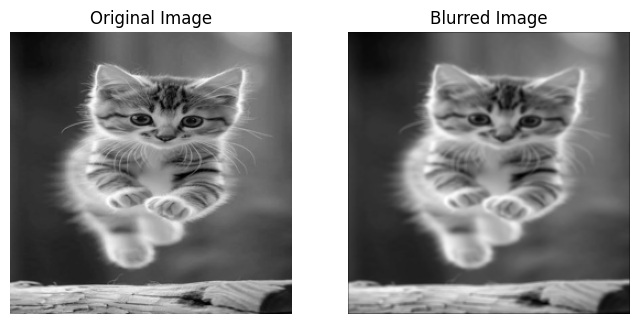

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image


image = Image.open("catsample.jpg").convert("L")

image = image.resize((256, 256))


image = np.array(image, dtype=np.float32) / 255.0


image = np.expand_dims(image, axis=(0, -1))


blur_filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)


blur_filter = blur_filter.reshape(3, 3, 1, 1)


blurred_image = tf.nn.conv2d(
    image,
    blur_filter,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

blurred_image = blurred_image.numpy().squeeze()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_image, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.show()